In [ ]:
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras.models as M
import tensorflow.keras.layers as L
import tensorflow.keras.backend as K
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
print(tf.__version__)

2.19.0


In [ ]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
print(f'Размеры датасетов:\n  x_train={x_train.shape}\n  x_test={x_test.shape}')

Размеры датасетов:
  x_train=(50000, 32, 32, 3)
  x_test=(10000, 32, 32, 3)


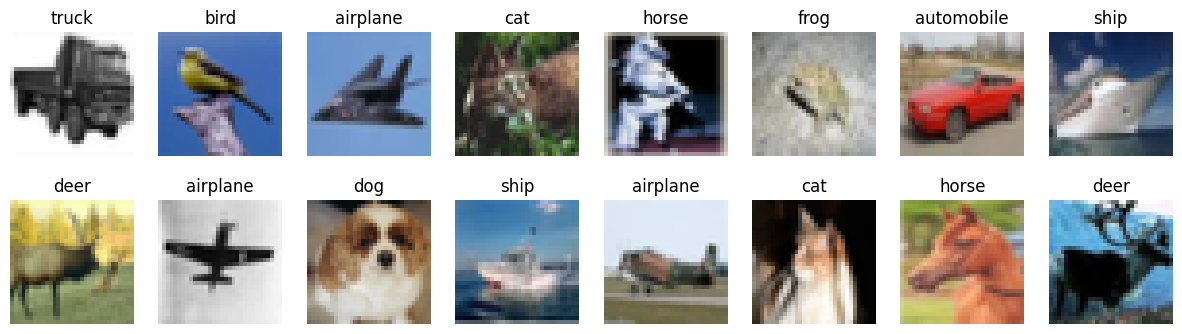

In [ ]:
NUM_CLASSES = 10
cifar_10_classes = ['airplane',
                    'automobile',
                    'bird',
                    'cat',
                    'deer',
                    'dog',
                    'frog',
                    'horse',
                    'ship',
                    'truck']
# примеры картинок
cols, rows = 8, 2
fig = plt.figure(figsize=(2 * cols - 1, 2.5 * rows - 1))
for i in range(cols):
  for j in range(rows):
    random_index = np.random.randint(0, len(y_train))
    ax = fig.add_subplot(rows, cols, i * rows + j + 1)
    ax.grid('off')
    ax.axis('off')
    ax.imshow(x_train[random_index, :])
    ax.set_title(cifar_10_classes[y_train[random_index, 0]])
plt.show()

In [ ]:
x_train = x_train/255 - 0.5
x_test = x_test/255 - 0.5

In [ ]:
# Конвертируйте метки в np.array
y_train2 = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test2 = keras.utils.to_categorical(y_test, NUM_CLASSES)

In [ ]:
default_model = M.Sequential()

default_model.add(L.Conv2D(16, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)))
default_model.add(L.Conv2D(16, (3, 3), padding='same', activation='relu'))
default_model.add(L.MaxPooling2D(pool_size=(2, 2)))
default_model.add(L.Dropout(0.25))

default_model.add(L.Conv2D(32, (3, 3), padding='same', activation='relu'))
default_model.add(L.Conv2D(32, (3, 3), padding='same', activation='relu'))
default_model.add(L.MaxPooling2D(pool_size=(2, 2)))
default_model.add(L.Dropout(0.25))

default_model.add(L.Conv2D(64, (3, 3), padding='same', activation='relu'))
default_model.add(L.Conv2D(64, (3, 3), padding='same', activation='relu'))
default_model.add(L.MaxPooling2D(pool_size=(2, 2)))
default_model.add(L.Dropout(0.25))

default_model.add(L.Flatten())
default_model.add(L.Dense(256, activation='relu'))
default_model.add(L.Dropout(0.5))
default_model.add(L.Dense(NUM_CLASSES, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
default_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
history = default_model.fit(
    x_train, y_train2,
    batch_size=32,
    epochs=10,
    validation_data=(x_test, y_test2)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.3085 - loss: 1.8376 - val_accuracy: 0.5475 - val_loss: 1.2468
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5216 - loss: 1.3046 - val_accuracy: 0.6242 - val_loss: 1.0637
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.5953 - loss: 1.1343 - val_accuracy: 0.6511 - val_loss: 0.9808
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6313 - loss: 1.0397 - val_accuracy: 0.6659 - val_loss: 0.9406
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6574 - loss: 0.9691 - val_accuracy: 0.7023 - val_loss: 0.8424
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6752 - loss: 0.9154 - val_accuracy: 0.7152 - val_loss: 0.8095
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6875 - loss: 0.8890 - val_accuracy: 0.7227 - val_loss: 0.7893
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6985 - loss: 0.8572

In [ ]:
test_loss, test_acc = default_model.evaluate(x_test, y_test2, verbose=0)

In [ ]:
print(f"Default model accuracy: {test_acc:.4f}")

Default model accuracy: 0.7538


In [ ]:
# Замена активации с relu на sigmoid
sigmoid_model = M.Sequential(name="sigmoid_adam")

sigmoid_model.add(L.Conv2D(16, (3, 3), padding='same', activation='sigmoid', input_shape=(32, 32, 3)))
sigmoid_model.add(L.Conv2D(16, (3, 3), padding='same', activation='sigmoid'))
sigmoid_model.add(L.MaxPooling2D(pool_size=(2, 2)))
sigmoid_model.add(L.Dropout(0.25))

sigmoid_model.add(L.Conv2D(32, (3, 3), padding='same', activation='sigmoid'))
sigmoid_model.add(L.Conv2D(32, (3, 3), padding='same', activation='sigmoid'))
sigmoid_model.add(L.MaxPooling2D(pool_size=(2, 2)))
sigmoid_model.add(L.Dropout(0.25))

sigmoid_model.add(L.Conv2D(64, (3, 3), padding='same', activation='sigmoid'))
sigmoid_model.add(L.Conv2D(64, (3, 3), padding='same', activation='sigmoid'))
sigmoid_model.add(L.MaxPooling2D(pool_size=(2, 2)))
sigmoid_model.add(L.Dropout(0.25))

sigmoid_model.add(L.Flatten())
sigmoid_model.add(L.Dense(256, activation='sigmoid'))
sigmoid_model.add(L.Dropout(0.5))
sigmoid_model.add(L.Dense(NUM_CLASSES, activation='softmax'))

In [ ]:
sigmoid_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
history_sigmoid = sigmoid_model.fit(
    x_train, y_train2,
    batch_size=32,
    epochs=10,
    validation_data=(x_test, y_test2))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.0982 - loss: 2.3364 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0961 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1005 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.1024 - loss: 2.3038 - val_accuracy: 0.1000 - val_loss: 2.3030
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.0986 - loss: 2.3043 - val_accuracy: 0.1000 - val_loss: 2.3034
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1008 - loss: 2.3036 - val_accuracy: 0.1000 - val_loss: 2.3034
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.0985 - loss: 2.3060 - val_accuracy: 0.1000 - val_loss: 2.3033
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.0994 - loss: 2.3042 -

In [ ]:
test_loss_sigmoid, test_acc_sigmoid = sigmoid_model.evaluate(x_test, y_test2, verbose=0)
print(f"Sigmoid активация: Accuracy = {test_acc_sigmoid:.4f}")

Sigmoid активация: Accuracy = 0.1000


In [ ]:
# SGD оптимизатор
# ниже все как в defulat_model
model_sgd = M.Sequential()

model_sgd.add(L.Conv2D(16, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)))
model_sgd.add(L.Conv2D(16, (3, 3), padding='same', activation='relu'))
model_sgd.add(L.MaxPooling2D(pool_size=(2, 2)))
model_sgd.add(L.Dropout(0.25))

model_sgd.add(L.Conv2D(32, (3, 3), padding='same', activation='relu'))
model_sgd.add(L.Conv2D(32, (3, 3), padding='same', activation='relu'))
model_sgd.add(L.MaxPooling2D(pool_size=(2, 2)))
model_sgd.add(L.Dropout(0.25))

model_sgd.add(L.Conv2D(64, (3, 3), padding='same', activation='relu'))
model_sgd.add(L.Conv2D(64, (3, 3), padding='same', activation='relu'))
model_sgd.add(L.MaxPooling2D(pool_size=(2, 2)))
model_sgd.add(L.Dropout(0.25))

model_sgd.add(L.Flatten())
model_sgd.add(L.Dense(256, activation='relu'))
model_sgd.add(L.Dropout(0.5))
model_sgd.add(L.Dense(NUM_CLASSES, activation='softmax'))

In [ ]:
model_sgd.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

In [ ]:
history_sgd = model_sgd.fit(
    x_train, y_train2,
    batch_size=32,
    epochs=10,
    validation_data=(x_test, y_test2)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.1428 - loss: 2.2694 - val_accuracy: 0.3339 - val_loss: 1.8206
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3068 - loss: 1.8434 - val_accuracy: 0.3611 - val_loss: 1.7188
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.3585 - loss: 1.7178 - val_accuracy: 0.4226 - val_loss: 1.5620
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3930 - loss: 1.6294 - val_accuracy: 0.4540 - val_loss: 1.4761
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4284 - loss: 1.5366 - val_accuracy: 0.4658 - val_loss: 1.4213
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4598 - loss: 1.4623 - val_accuracy: 0.5223 - val_loss: 1.3121
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4882 - loss: 1.3954 - val_accuracy: 0.5419 - val_loss: 1.2661
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5164 - loss: 1.3346 

In [ ]:
test_loss_sgd, test_acc_sgd = model_sgd.evaluate(x_test, y_test2, verbose=0)
print(f"SGD оптимизатор: Accuracy = {test_acc_sgd:.4f}")

SGD оптимизатор: Accuracy = 0.5857


In [ ]:
# Добавление BatchNormalization
batch_norm_model = M.Sequential()

batch_norm_model.add(L.Conv2D(16, (3, 3), padding='same', input_shape=(32, 32, 3)))
batch_norm_model.add(L.BatchNormalization())
batch_norm_model.add(L.Activation('relu'))
batch_norm_model.add(L.Conv2D(16, (3, 3), padding='same'))
batch_norm_model.add(L.BatchNormalization())
batch_norm_model.add(L.Activation('relu'))
batch_norm_model.add(L.MaxPooling2D(pool_size=(2, 2)))
batch_norm_model.add(L.Dropout(0.25))

batch_norm_model.add(L.Conv2D(32, (3, 3), padding='same'))
batch_norm_model.add(L.BatchNormalization())
batch_norm_model.add(L.Activation('relu'))
batch_norm_model.add(L.Conv2D(32, (3, 3), padding='same'))
batch_norm_model.add(L.BatchNormalization())
batch_norm_model.add(L.Activation('relu'))
batch_norm_model.add(L.MaxPooling2D(pool_size=(2, 2)))
batch_norm_model.add(L.Dropout(0.25))

batch_norm_model.add(L.Conv2D(64, (3, 3), padding='same'))
batch_norm_model.add(L.BatchNormalization())
batch_norm_model.add(L.Activation('relu'))
batch_norm_model.add(L.Conv2D(64, (3, 3), padding='same'))
batch_norm_model.add(L.BatchNormalization())
batch_norm_model.add(L.Activation('relu'))
batch_norm_model.add(L.MaxPooling2D(pool_size=(2, 2)))
batch_norm_model.add(L.Dropout(0.25))

batch_norm_model.add(L.Flatten())
batch_norm_model.add(L.Dense(256))
batch_norm_model.add(L.BatchNormalization())
batch_norm_model.add(L.Activation('relu'))
batch_norm_model.add(L.Dropout(0.5))
batch_norm_model.add(L.Dense(NUM_CLASSES, activation='softmax'))

In [ ]:
batch_norm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'])

In [ ]:
batch_norm_model_history = batch_norm_model.fit(
    x_train, y_train2,
    batch_size=32,
    epochs=10,
    validation_data=(x_test, y_test2))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.3498 - loss: 1.8710 - val_accuracy: 0.6069 - val_loss: 1.0944
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5733 - loss: 1.1927 - val_accuracy: 0.6799 - val_loss: 0.9112
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6408 - loss: 1.0210 - val_accuracy: 0.6861 - val_loss: 0.8877
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6714 - loss: 0.9308 - val_accuracy: 0.7246 - val_loss: 0.7851
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6986 - loss: 0.8671 - val_accuracy: 0.7287 - val_loss: 0.7816
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7183 - loss: 0.8117 - val_accuracy: 0.7332 - val_loss: 0.7742
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7336 - loss: 0.7719 - val_accuracy: 0.7609 - val_loss: 0.6834
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7375 - loss: 0.7512 

In [ ]:
test_loss_bn, test_acc_bn = batch_norm_model.evaluate(x_test, y_test2, verbose=0)
print(f"BatchNormalization: Accuracy = {test_acc_bn:.4f}")

BatchNormalization: Accuracy = 0.7968


In [ ]:
# BN + Sigmoid
bn_sig_model = M.Sequential()

bn_sig_model.add(L.Conv2D(16, (3, 3), padding='same', input_shape=(32, 32, 3)))
bn_sig_model.add(L.BatchNormalization())
bn_sig_model.add(L.Activation('sigmoid'))
bn_sig_model.add(L.Conv2D(16, (3, 3), padding='same'))
bn_sig_model.add(L.BatchNormalization())
bn_sig_model.add(L.Activation('sigmoid'))
bn_sig_model.add(L.MaxPooling2D(pool_size=(2, 2)))
bn_sig_model.add(L.Dropout(0.25))

bn_sig_model.add(L.Conv2D(32, (3, 3), padding='same'))
bn_sig_model.add(L.BatchNormalization())
bn_sig_model.add(L.Activation('sigmoid'))
bn_sig_model.add(L.Conv2D(32, (3, 3), padding='same'))
bn_sig_model.add(L.BatchNormalization())
bn_sig_model.add(L.Activation('sigmoid'))
bn_sig_model.add(L.MaxPooling2D(pool_size=(2, 2)))
bn_sig_model.add(L.Dropout(0.25))

bn_sig_model.add(L.Conv2D(64, (3, 3), padding='same'))
bn_sig_model.add(L.BatchNormalization())
bn_sig_model.add(L.Activation('sigmoid'))
bn_sig_model.add(L.Conv2D(64, (3, 3), padding='same'))
bn_sig_model.add(L.BatchNormalization())
bn_sig_model.add(L.Activation('sigmoid'))
bn_sig_model.add(L.MaxPooling2D(pool_size=(2, 2)))
bn_sig_model.add(L.Dropout(0.25))

bn_sig_model.add(L.Flatten())
bn_sig_model.add(L.Dense(256))
bn_sig_model.add(L.BatchNormalization())
bn_sig_model.add(L.Activation('sigmoid'))
bn_sig_model.add(L.Dropout(0.5))
bn_sig_model.add(L.Dense(NUM_CLASSES, activation='softmax'))

In [ ]:
bn_sig_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'])

In [ ]:
history_bn_sigmoid = bn_sig_model.fit(
    x_train, y_train2,
    batch_size=32,
    epochs=10,
    validation_data=(x_test, y_test2))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.2471 - loss: 2.0856 - val_accuracy: 0.4630 - val_loss: 1.4795
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4461 - loss: 1.5165 - val_accuracy: 0.4985 - val_loss: 1.3500
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5128 - loss: 1.3645 - val_accuracy: 0.5843 - val_loss: 1.1782
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5555 - loss: 1.2502 - val_accuracy: 0.6074 - val_loss: 1.0892
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5852 - loss: 1.1766 - val_accuracy: 0.6523 - val_loss: 0.9841
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6041 - loss: 1.1191 - val_accuracy: 0.6765 - val_loss: 0.9129
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6321 - loss: 1.0493 - val_accuracy: 0.6590 - val_loss: 0.9843
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6463 - loss: 1.0073 

In [ ]:
test_loss_bn_sigmoid, test_acc_bn_sigmoid = bn_sig_model.evaluate(x_test, y_test2, verbose=0)
print(f"BatchNormalization + Sigmoid: Accuracy = {test_acc_bn_sigmoid:.4f}")

BatchNormalization + Sigmoid: Accuracy = 0.7266


In [ ]:
# Итоговая таблица результатов
import pandas as pd
results = {
    'Архитектура': [
        'Дефолтная (ReLU+Adam)',
        'Sigmoid активация',
        'SGD оптимизатор',
        'BatchNormalization',
        'BatchNormalization + Sigmoid'
    ],
    'Optimizer': ['Adam', 'Adam', 'SGD', 'Adam', 'Adam'],
    'Activation': ['ReLU', 'Sigmoid', 'ReLU', 'ReLU', 'Sigmoid'],
    'BatchNorm': ['Нет', 'Нет', 'Нет', 'Да', 'Да'],
    'Accuracy': [
        test_acc,
        test_acc_sigmoid,
        test_acc_sgd,
        test_acc_bn,
        test_acc_bn_sigmoid
    ],
    'Loss': [
        test_loss,
        test_loss_sigmoid,
        test_loss_sgd,
        test_loss_bn,
        test_loss_bn_sigmoid
    ]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False)

In [ ]:
results_df

,Архитектура,Optimizer,Activation,BatchNorm,Accuracy,Loss
3,BatchNormalization,Adam,ReLU,Да,0.7968,0.589471
0,Дефолтная (ReLU+Adam),Adam,ReLU,Нет,0.7538,0.721775
4,BatchNormalization + Sigmoid,Adam,Sigmoid,Да,0.7266,0.785892
2,SGD оптимизатор,SGD,ReLU,Нет,0.5857,1.156053
1,Sigmoid активация,Adam,Sigmoid,Нет,0.1000,2.303302
